In [133]:
import jax 
import jax.numpy as jnp

# enable 64-bit precision
from jax.config import config
config.update("jax_enable_x64", False)

/tmp/ipykernel_9053/4259490379.py:5: DeprecationWarning: Accessing jax.config via the jax.config submodule is deprecated.
  from jax.config import config


In [134]:
from matplotlib.patches import Ellipse
import numpy as np

def plot_cov_ellipse(cov, pos, nstd=2, ax=None, **kwargs):
    """
    Plots an `nstd` sigma error ellipse based on the specified covariance
    matrix (`cov`). Additional keyword arguments are passed on to the 
    ellipse patch artist.

    Parameters
    ----------
        cov : The 2x2 covariance matrix to base the ellipse on
        pos : The location of the center of the ellipse. Expects a 2-element
            sequence of [x0, y0].
        nstd : The radius of the ellipse in numbers of standard deviations.
            Defaults to 2 standard deviations.
        ax : The axis that the ellipse will be plotted on. Defaults to the 
            current axis.
        Additional keyword arguments are pass on to the ellipse patch.

    Returns
    -------
        A matplotlib ellipse artist
    """
    def eigsorted(cov):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        return vals[order], vecs[:,order]

    if ax is None:
        ax = plt.gca()

    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height are "full" widths, not radius
    width, height = 2 * nstd * np.sqrt(vals)
    ellip = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)

    ax.add_artist(ellip)
    return ellip

In [135]:

def generate_sigma_point(mu0, cov0, alpha = 1., beta = 2., kappa = 0.):
        
    with jax.ensure_compile_time_eval():
        L = mu0.shape[0]
        lambda_ = alpha**2 * (L + kappa) - L
        weights_mean_0 = jnp.atleast_1d(lambda_ / (L + lambda_))
        weights_cov_0 = jnp.atleast_1d(weights_mean_0 + (1 - alpha**2 + beta))
        weights_mean_cov_1_L = 1 / (2*(L + lambda_)) * jnp.ones(2*L)
        
        weights_mean = jnp.concatenate([weights_mean_0, weights_mean_cov_1_L], axis=0)
        weights_cov = jnp.concatenate([weights_cov_0, weights_mean_cov_1_L], axis=0)
        
    sqrt_cov = jnp.linalg.cholesky((L + lambda_) * cov0)
    sigma_points_0 = mu0[None,:]
    sigma_points_1_L = mu0 + sqrt_cov 
    sigma_points_L_2L = mu0 - sqrt_cov
    sigma_points = jnp.concatenate([sigma_points_0, sigma_points_1_L, sigma_points_L_2L], axis=0)
    

    return sigma_points, weights_mean, weights_cov

In [136]:
def uncented_transform(sigma_points, weights_mean, weights_cov, noise_cov = None, mean_fn = None, cov_fn = None):
    if mean_fn is not None:
        mean = mean_fn(sigma_points, weights_mean)
    else:
        mean = jnp.dot(weights_mean, sigma_points)
    
    if cov_fn is not None:
        cov = cov_fn(sigma_points, mean, weights_cov)    
    else:
        diff = sigma_points - mean[None,:]
        cov = jnp.dot(weights_cov * diff.T, diff)
        
    if noise_cov is not None:
        cov += noise_cov
        
    return mean, cov
    

In [137]:
mu0 = jnp.array([0, 0])
cov0 = jnp.array([[1, 0], [0, 1]])


In [138]:
samples = jax.random.multivariate_normal(jax.random.PRNGKey(0), mu0, cov0, (10000,))

In [178]:
def f(x):
    y =  jnp.cos(x) + jnp.sin(x) 
    A = jnp.array([[1, 0], [1, 1]])
    return jnp.dot(A, y.T).T* x**3

transformed_samples = f(samples)

In [192]:
sigma_points, weights_mean, weights_cov = generate_sigma_point(mu0, cov0, alpha = 1.)
sigma_points, weights_mean

(Array([[ 0.       ,  0.       ],
        [ 1.4142135,  0.       ],
        [ 0.       ,  1.4142135],
        [-1.4142135,  0.       ],
        [ 0.       , -1.4142135]], dtype=float32, weak_type=True),
 Array([0.  , 0.25, 0.25, 0.25, 0.25], dtype=float32))

In [193]:
weights_cov.sum()

Array(3., dtype=float32)

In [194]:
predicted_sigma_points = jax.vmap(f)(sigma_points)
mu1, cov1 = uncented_transform(predicted_sigma_points, weights_mean, weights_cov, jnp.array([[0, 0], [0, 0]]))

In [195]:
mu1

Array([1.3966048, 1.3966048], dtype=float32)

In [196]:
import matplotlib.pyplot as plt

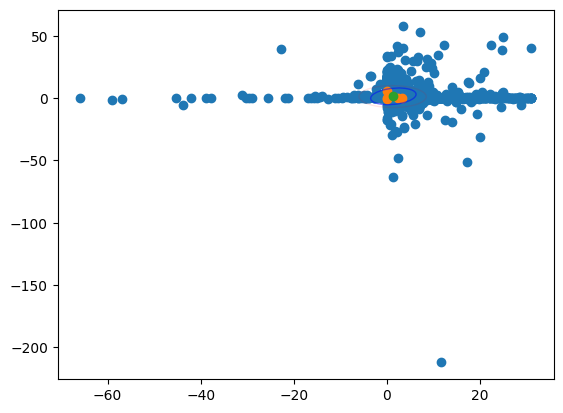

In [199]:
plt.scatter(transformed_samples[:,0], transformed_samples[:,1])
plt.scatter(predicted_sigma_points[:,0], predicted_sigma_points[:,1])
plt.scatter(mu1[0], mu1[1])
# Draw ellipse for cov1
plot_cov_ellipse(cov1, mu1, nstd=2, color='blue', alpha=0.5, fill=False)
cov1_true = jnp.cov(transformed_samples.T)
plot_cov_ellipse(cov1_true, jnp.mean(transformed_samples, axis=0), nstd=2, color='red', alpha=0.1, fill=False)


In [185]:
cov1

Array([[0.00119234, 0.00079254],
       [0.00079254, 0.00238413]], dtype=float32)

In [152]:
import numpy as np

def unscented_transform(mean, cov, func, alpha=1e-3, beta=2, kappa=0):
    n = mean.shape[0]
    lambda_ = alpha**2 * (n + kappa) - n

    # Compute sigma points
    sigma_points = np.zeros((2 * n + 1, n))
    sigma_points[0] = mean
    sqrt_matrix = np.linalg.cholesky((n + lambda_) * cov)

    for i in range(n):
        sigma_points[i + 1] = mean + sqrt_matrix[:, i]
        sigma_points[n + i + 1] = mean - sqrt_matrix[:, i]

    # Compute weights
    weights_mean = np.zeros(2 * n + 1)
    weights_cov = np.zeros(2 * n + 1)
    weights_mean[0] = lambda_ / (n + lambda_)
    weights_cov[0] = lambda_ / (n + lambda_) + (1 - alpha**2 + beta)
    

    for i in range(1, 2 * n + 1):
        weights_mean[i] = weights_cov[i] = 1 / (2 * (n + lambda_))
        
    print(weights_mean, weights_cov)

    # Propagate sigma points through the nonlinear function
    transformed_sigma_points = np.array([func(point) for point in sigma_points])
    print(transformed_sigma_points)
    # Compute the mean of the transformed distribution
    mean_transformed = np.sum(weights_mean[:, None] * transformed_sigma_points, axis=0)
    print(weights_mean,mean_transformed)
    # Compute the covariance of the transformed distribution
    diff = transformed_sigma_points - mean_transformed
    cov_transformed = np.zeros((n, n))
    for i in range(2 * n + 1):
        cov_transformed += weights_cov[i] * np.outer(diff[i], diff[i])

    return mean_transformed, cov_transformed, sigma_points,  transformed_sigma_points, weights_mean, weights_cov


In [44]:
mean_true, cov_true, sigma_points_true, predicted_sigma_points_true, weights_mean_true, weights_cov_true = unscented_transform(mu0, cov0, f)

[-999998.99997124  249999.99999281  249999.99999281  249999.99999281
  249999.99999281] [-999995.99997224  249999.99999281  249999.99999281  249999.99999281
  249999.99999281]
[[1.        2.       ]
 [1.0014153 2.0014133]
 [1.        2.0014153]
 [0.9985868 1.9985847]
 [1.        1.9985868]]
[-999998.99997124  249999.99999281  249999.99999281  249999.99999281
  249999.99999281] [1.50663948 2.02980232]


In [59]:
np.sum(weights_mean[:, None] * predicted_sigma_points, axis=0)

Array([-120.078125, -241.1875  ], dtype=float32)

In [55]:
weights_mean - weights_mean_true

Array([0., 0., 0., 0., 0.], dtype=float32)

In [56]:
weights_cov - weights_cov_true

Array([0., 0., 0., 0., 0.], dtype=float32)

In [51]:
predicted_sigma_points - predicted_sigma_points_true

Array([[ 0.0000000e+00,  0.0000000e+00],
       [-4.3666363e-04, -4.3678284e-04],
       [ 0.0000000e+00, -4.3678284e-04],
       [-4.9591064e-05, -4.9591064e-05],
       [ 0.0000000e+00, -4.9591064e-05]], dtype=float32)

In [48]:
sigma_points_true - sigma_points

Array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)